# 07 — Assemble Feature Matrix

Merge DEM-derived topographic features, ERA5-Land climate features, and
NDVI composite into one tidy DataFrame, add interaction terms, and save
as `../data/df.pkl`.

**Column groups:**

| Group | Columns |
|---|---|
| Target | `label` (1 = coffee, 0 = background) |
| Topography | `elev_*`, `slope_*`, `aspect_*`, `curve_*`, `total_relief*`, `dist_coast_m` |
| Climate | `temp_*`, `gdd`, `cold_months`, `precip_*`, `wind_*` |
| Vegetation | `ndvi_median` |
| Soil | `drain_ord`, `restrictiondepth_cm`, `awc_mean`, `ph_0_30cm`, `om_0_30cm`, `sand_0_30cm`, `silt_0_30cm`, `clay_0_30cm`, `cec_0_30cm`, `soil_null` |
| Interaction | `coast_x_elev`, `temp_x_elev` |
| Region | `region` (`kona` / `kau`) — derived from centroid longitude |
| Metadata (excluded from model) | `plot_id`, `geometry` |


In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np

pd.set_option('display.max_columns', None)

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


In [2]:
# Load components
elev_feat    = pd.read_pickle('../data/plot_elev_features.pkl')
climate_feat = pd.read_pickle('../data/plot_climate_features.pkl')
ndvi_feat    = pd.read_pickle('../data/plot_ndvi_features.pkl')
soil_feat    = pd.read_pickle('../data/plot_soil_features.pkl')

print('Elevation features:', elev_feat.shape)
print('Climate features:',   climate_feat.shape)
print('NDVI features:',      ndvi_feat.shape)
print('Soil features:',      soil_feat.shape)


Elevation features: (10211, 20)
Climate features: (385, 18)
NDVI features: (471, 2)
Soil features: (10211, 17)


In [3]:
# Merge on plot_id
SOIL_COLS = [
    'plot_id',
    'drain_ord', 'restrictiondepth_cm', 'awc_mean',
    'ph_0_30cm', 'om_0_30cm',
    'sand_0_30cm', 'silt_0_30cm', 'clay_0_30cm', 'cec_0_30cm',
    'soil_null',
]

df = (elev_feat
      .merge(climate_feat, on='plot_id', how='left')
      .merge(ndvi_feat,    on='plot_id', how='left')
      .merge(soil_feat[SOIL_COLS], on='plot_id', how='left'))

print(f'Merged: {len(df)} cells')
print('Label distribution:')
print(df['label'].value_counts())


Merged: 10211 cells
Label distribution:
0    9740
1     471
Name: label, dtype: int64


In [4]:
# ── Interaction terms ─────────────────────────────────────────────────────────
# Distance to coast × elevation: cloud-belt inversion layer
df['coast_x_elev'] = df['dist_coast_m'] * df['elev_mean']

# Temperature × elevation: lapse-rate interaction (coffee sweet spot)
if 'temp_mean' in df.columns:
    df['temp_x_elev'] = df['temp_mean'] * df['elev_mean']

df['dist_coast_log'] = np.log1p(df['dist_coast_m'])

print('Interaction terms added.')

Interaction terms added.


In [5]:
# ── Assign region from centroid longitude ─────────────────────────────────────
# Split at the natural gap between Kona (W) and Ka'u (E) coffee belts
SPLIT_LON = -155.7279

gdf_elev = gpd.GeoDataFrame(
    elev_feat[['plot_id', 'geometry']], geometry='geometry', crs='EPSG:4326'
)
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    cx = gdf_elev.geometry.centroid.x

region_map = cx.apply(lambda x: 'kona' if x < SPLIT_LON else 'kau')
region_map.index = gdf_elev['plot_id']
df['region'] = df['plot_id'].map(region_map)

print('Region distribution (all cells):')
print(df['region'].value_counts())


Region distribution (all cells):
kona    7475
kau     2736
Name: region, dtype: int64


In [6]:
# ── Drop metadata columns before saving feature matrix ───────────────────────
META_COLS = ['geometry']
df_model = pd.DataFrame(df.drop(columns=META_COLS, errors='ignore'))

# Impute restrictiondepth_cm with median — gSSURGO omits restriction depth for
# many Ka'u volcanic soil map units even when other soil attributes are present.
# Without imputation, 43 coffee cells (35 Ka'u) are silently dropped, leaving
# only 27 Ka'u rows in the final dataset.
rd_median = df_model['restrictiondepth_cm'].median()
n_imputed = df_model['restrictiondepth_cm'].isna().sum()
df_model['restrictiondepth_cm'] = df_model['restrictiondepth_cm'].fillna(rd_median)
print(f'Imputed restrictiondepth_cm for {n_imputed} rows (median = {rd_median:.0f} cm)')

# ── Save full-grid pickle (topo + soil + geometry) for Part B suitability map ─
# Includes all 10k+ cells. Non-coffee cells have NaN climate/NDVI (expected).
# soil_null==1 flags cells where SSURGO returned no map unit (young lava, ocean edges).
TOPO_SOIL_COLS = [
    'plot_id', 'geometry', 'label', 'region',
    'elev_mean', 'elev_dev_mean', 'slope_max',
    'aspect_sin', 'aspect_cos', 'total_relief', 'local_relief', 'dist_coast_m',
    'drain_ord', 'restrictiondepth_cm', 'awc_mean',
    'ph_0_30cm', 'om_0_30cm',
    'sand_0_30cm', 'silt_0_30cm', 'clay_0_30cm', 'cec_0_30cm',
    'soil_null'
]
plot_all = df[[c for c in TOPO_SOIL_COLS if c in df.columns]].copy()
plot_all['restrictiondepth_cm'] = df_model['restrictiondepth_cm']  # use imputed values
n_with_soil = (plot_all['soil_null'].fillna(1) == 0).sum()
plot_all.to_pickle('../data/plot_all_features.pkl')
print(f'Saved plot_all_features.pkl  ({len(plot_all):,} cells, {n_with_soil:,} with complete soil data)')

# Drop rows with any remaining NaN — these are the ~86 coffee cells where
# GEE climate extraction was never run (no climate data at all).
n_before = len(df_model)
df_model = df_model.dropna()
print(f'Dropped {n_before - len(df_model)} rows with NaN; {len(df_model)} rows remain')
print(f'Region split: {dict(df_model[df_model.label==1]["region"].value_counts())}')

df_model.to_pickle('../data/df.pkl')
print('Saved ../data/df.pkl')
df_model.head(3)

Imputed restrictiondepth_cm for 1544 rows (median = 74 cm)
Saved plot_all_features.pkl  (10,211 cells, 10,033 with complete soil data)
Dropped 9894 rows with NaN; 317 rows remain
Region split: {'kona': 258, 'kau': 59}
Saved ../data/df.pkl


,plot_id,label,slope_max,aspect_mean,elev_min,elev_max,elev_mean,elev_dev_mean,curve_mean,pro_curve_mean,plan_curve_mean,total_relief,total_relief_log,local_relief,aspect_sin,aspect_cos,slope_x,slope_y,dist_coast_m,temp_mean,temp_min,temp_max,temp_range,gdd,cold_months,heat_months,precip_annual,precip_dry,precip_wet,precip_dry_frac,wind_speed_mean,wind_speed_max,wind_u_mean,wind_v_mean,wind_dir_sin,wind_dir_cos,ndvi_median,drain_ord,restrictiondepth_cm,awc_mean,ph_0_30cm,om_0_30cm,sand_0_30cm,silt_0_30cm,clay_0_30cm,cec_0_30cm,soil_null,coast_x_elev,temp_x_elev,dist_coast_log,region
211,211,1,19.886174,147.749423,293.637482,335.592712,313.210743,-176.653499,0.000203,0.000202,-0.000016,41.955231,3.760158,19.573261,0.533623,-0.845722,-0.149384,0.094257,61470.959834,23.758753,22.642704,25.305053,2.662349,1485.945372,0.0,0.0,888.705783,324.657743,564.048041,0.365315,6.723894,8.626124,-6.611892,-1.133838,-0.97985,-0.153551,0.749277,2.0,74.0,0.2,5.8,2.5,30.0,50.0,20.0,35.0,0,1.925336e+07,7441.496815,11.026336,kau
212,212,1,12.522217,148.308548,279.686493,315.917267,297.052644,-192.811597,0.000107,0.000184,-0.000082,36.230774,3.617136,17.366151,0.525345,-0.850889,-0.108357,0.066900,61680.242489,23.758753,22.642704,25.305053,2.662349,1485.945372,0.0,0.0,888.705783,324.657743,564.048041,0.365315,6.723894,8.626124,-6.611892,-1.133838,-0.97985,-0.153551,0.602482,2.0,74.0,0.2,5.8,2.5,30.0,50.0,20.0,35.0,0,1.832228e+07,7057.600538,11.029735,kau
213,213,1,14.833517,130.076522,264.462128,297.900360,282.900363,-206.963879,0.000749,0.000042,0.000694,33.438232,3.539167,18.438235,0.765185,-0.643810,-0.090647,0.107736,61889.524649,23.758753,22.642704,25.305053,2.662349,1485.945372,0.0,0.0,888.705783,324.657743,564.048041,0.365315,6.723894,8.626124,-6.611892,-1.133838,-0.97985,-0.153551,0.680291,2.0,74.0,0.2,5.8,2.5,30.0,50.0,20.0,35.0,0,1.750857e+07,6721.359975,11.033122,kau


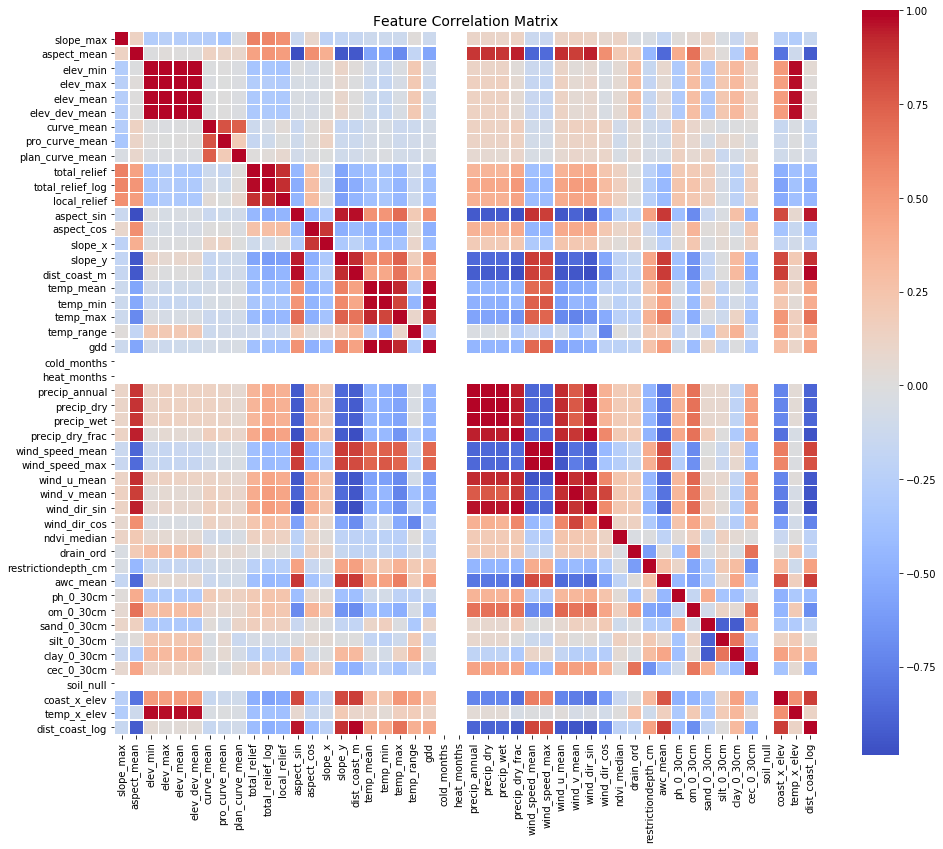

Feature matrix: 317 rows × 49 features


In [7]:
# ── Feature correlation heatmap ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

feat_cols = [c for c in df_model.columns if c not in ('plot_id', 'label')]
corr = df_model[feat_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax,
            linewidths=0.3, annot=False, square=True)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('../img/07_feature_correlation.png', dpi=150)
plt.show()
print(f'Feature matrix: {df_model.shape[0]} rows × {len(feat_cols)} features')